# Fraud Detection System with Explainable AI
### Internship Final Project — Tanvi
--

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded!")

 Libraries loaded!


In [2]:
df_trans = pd.read_csv('data/train_transaction.csv')
df_id    = pd.read_csv('data/train_identity.csv')

df = pd.merge(df_trans, df_id, on='TransactionID', how='left')

print(f"Transaction file : {df_trans.shape}")
print(f"Identity file    : {df_id.shape}")
print(f"Merged dataset   : {df.shape}")
df.head(10)

Transaction file : (590540, 394)
Identity file    : (144233, 41)
Merged dataset   : (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## TASK 1 — Data Loading, Merging & Exploratory Analysis

In [3]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes.value_counts())
print("\nFirst 10 rows:")
df.head(10)

Shape: (590540, 434)

Data Types:
 float64    399
str         31
int64        4
Name: count, dtype: int64

First 10 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Legitimate transactions : 569,877
Fraud transactions      : 20,663
Fraud rate              : 3.50%


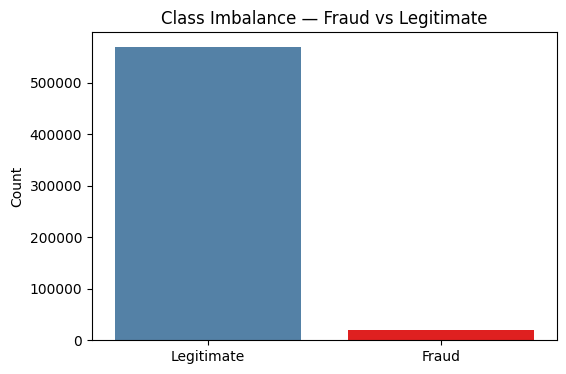

 Saved to charts/


In [4]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate   = df['isFraud'].mean() * 100

print(f"Legitimate transactions : {fraud_counts[0]:,}")
print(f"Fraud transactions      : {fraud_counts[1]:,}")
print(f"Fraud rate              : {fraud_rate:.2f}%")

plt.figure(figsize=(6,4))
sns.barplot(x=['Legitimate','Fraud'], y=fraud_counts.values, palette=['steelblue','red'])
plt.title('Class Imbalance — Fraud vs Legitimate')
plt.ylabel('Count')
plt.savefig('charts/class_imbalance.png')
plt.show()
print(" Saved to charts/")

Total columns         : 434
Columns to drop(>50%) : 214
Columns to keep       : 220


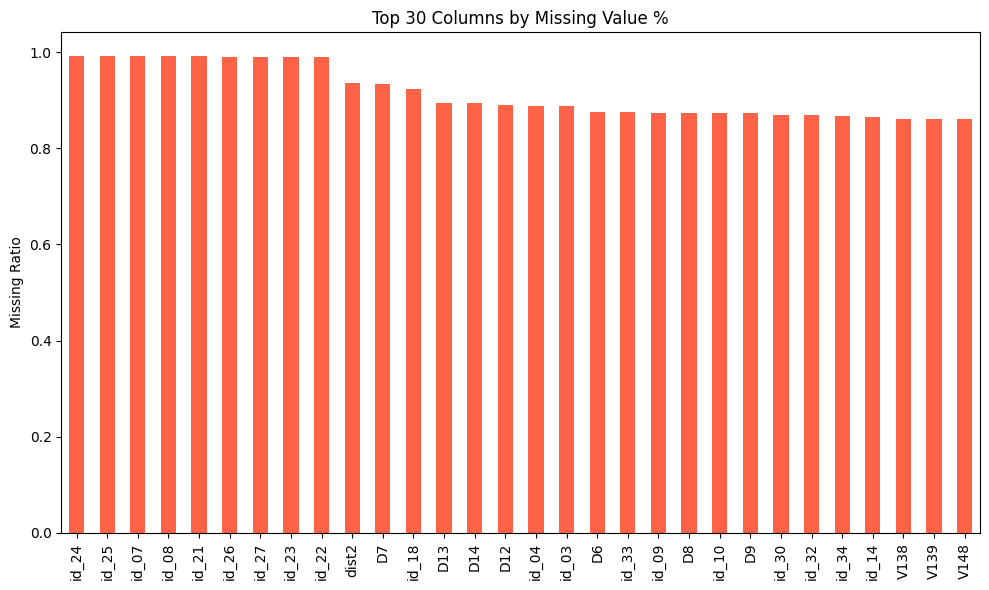

In [5]:
missing = df.isnull().mean().sort_values(ascending=False)
cols_to_drop = missing[missing > 0.5].index.tolist()

print(f"Total columns         : {df.shape[1]}")
print(f"Columns to drop(>50%) : {len(cols_to_drop)}")
print(f"Columns to keep       : {df.shape[1] - len(cols_to_drop)}")

# Plot top 30 missing columns
plt.figure(figsize=(10,6))
missing.head(30).plot(kind='bar', color='tomato')
plt.title('Top 30 Columns by Missing Value %')
plt.ylabel('Missing Ratio')
plt.tight_layout()
plt.savefig('charts/missing_values.png')
plt.show()

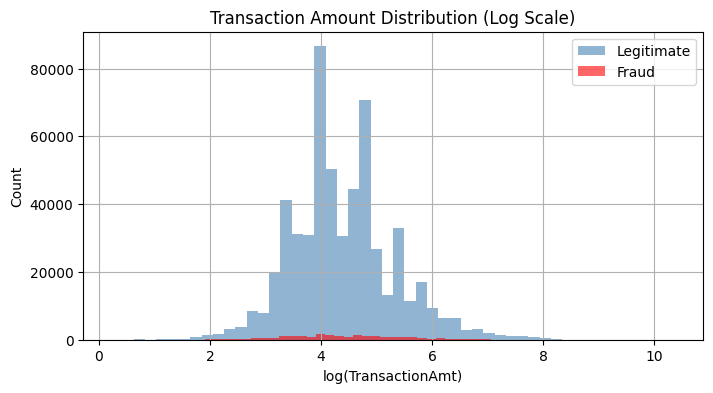

In [6]:
plt.figure(figsize=(8,4))
df[df['isFraud']==0]['TransactionAmt'].apply(np.log1p).hist(
    bins=50, alpha=0.6, label='Legitimate', color='steelblue')
df[df['isFraud']==1]['TransactionAmt'].apply(np.log1p).hist(
    bins=50, alpha=0.6, label='Fraud', color='red')
plt.xlabel('log(TransactionAmt)')
plt.ylabel('Count')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.legend()
plt.savefig('charts/amt_distribution.png')
plt.show()

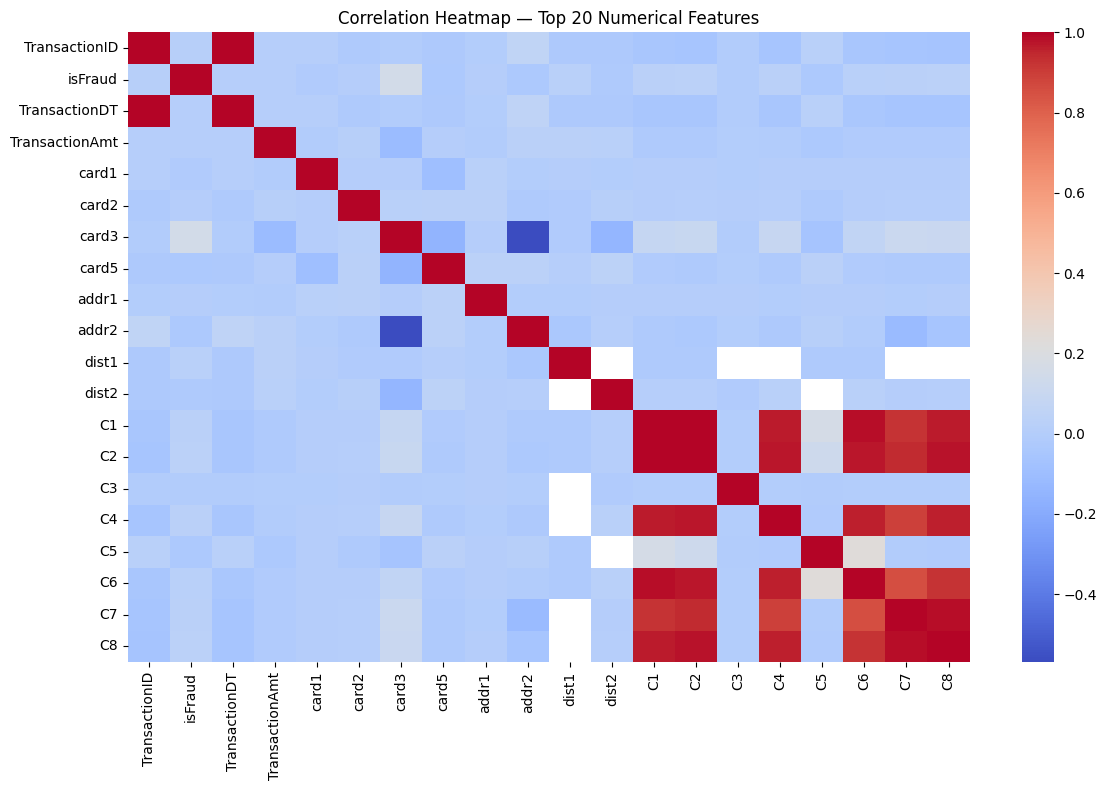

In [7]:
num_cols = df.select_dtypes(include=np.number).columns[:20]

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap — Top 20 Numerical Features')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png')
plt.show()

## TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

In [8]:
df_clean = df.drop(columns=cols_to_drop)

X = df_clean.drop(columns=['isFraud', 'TransactionID'])
y = df_clean['isFraud']

# Impute numerical with median, categorical with mode
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print(f"Remaining missing values: {X.isnull().sum().sum()}")
print(f"Features shape: {X.shape}")

Remaining missing values: 0
Features shape: (590540, 218)


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(" Label encoding done!")
print(f"Final feature shape: {X.shape}")

 Label encoding done!
Final feature shape: (590540, 218)


### Why Label Encoding?
Tree-based models like LightGBM and XGBoost handle integer-encoded 
categories natively. One-hot encoding would create hundreds of extra 
columns, slowing down training without any benefit for these models.

In [10]:
# Feature 1: How unusual is this transaction amount?
X['AmtToMeanRatio'] = X['TransactionAmt'] / X['TransactionAmt'].mean()

# Feature 2: What hour of day was the transaction?
X['HourOfDay'] = (X['TransactionDT'] / 3600) % 24

# Feature 3: Was it a night transaction? (fraud spikes at night)
X['IsNight'] = ((X['HourOfDay'] >= 22) | (X['HourOfDay'] <= 5)).astype(int)

# Feature 4: Is it an unusually high value transaction?
X['IsHighValue'] = (X['TransactionAmt'] > X['TransactionAmt'].quantile(0.95)).astype(int)

print(" 4 new features created:")
print("   - AmtToMeanRatio")
print("   - HourOfDay")
print("   - IsNight")
print("   - IsHighValue")

 4 new features created:
   - AmtToMeanRatio
   - HourOfDay
   - IsNight
   - IsHighValue


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# Use a sample to avoid memory issues (still 100k+ rows — more than enough)
fraud_rows  = df_clean[df_clean['isFraud'] == 1]
legit_rows  = df_clean[df_clean['isFraud'] == 0].sample(n=50000, random_state=42)
df_sample   = pd.concat([fraud_rows, legit_rows]).sample(frac=1, random_state=42)

X = df_sample.drop(columns=['isFraud', 'TransactionID'])
y = df_sample['isFraud']

# Redo feature engineering on sample
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

X['AmtToMeanRatio'] = X['TransactionAmt'] / X['TransactionAmt'].mean()
X['HourOfDay']      = (X['TransactionDT'] / 3600) % 24
X['IsNight']        = ((X['HourOfDay'] >= 22) | (X['HourOfDay'] <= 5)).astype(int)
X['IsHighValue']    = (X['TransactionAmt'] > X['TransactionAmt'].quantile(0.95)).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Before SMOTE — Fraud: {y_train.sum()} | Legit: {(y_train==0).sum()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Fraud: {y_train_res.sum()} | Legit: {(y_train_res==0).sum()}")

scaler = RobustScaler()
X_train_res   = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(" Split, SMOTE and Scaling done!")

Before SMOTE — Fraud: 16530 | Legit: 40000
After SMOTE  — Fraud: 40000 | Legit: 40000
 Split, SMOTE and Scaling done!


In [16]:
print(f"X_train_res shape  : {X_train_res.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train_res shape  : {y_train_res.shape}")
print(" All variables ready!")

X_train_res shape  : (80000, 222)
X_test_scaled shape: (14133, 222)
y_train_res shape  : (80000,)
 All variables ready!


## TASK 3 — Model Training, Comparison & Threshold Optimization

In [17]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score)

models = {
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                    class_weight='balanced', random_state=42, verbose=-1),
    'XGBoost' : xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                   scale_pos_weight=30, random_state=42,
                                   eval_metric='logloss', verbosity=0)
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'   : round(average_precision_score(y_test, y_prob), 4)
    }
    trained_models[name] = {'model': model, 'probs': y_prob}
    print(f" {name} done!")

print("\n Model Comparison:")
pd.DataFrame(results).T

Training LightGBM...
 LightGBM done!
Training XGBoost...
 XGBoost done!

 Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
LightGBM,0.8864,0.8638,0.7259,0.7889,0.9289,0.8840
XGBoost,0.5469,0.3910,0.9855,0.5599,0.9268,0.8763


In [18]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.035, random_state=42)
iso.fit(X_train_res)
iso_pred = (iso.predict(X_test_scaled) == -1).astype(int)

results['IsolationForest'] = {
    'Accuracy' : round(accuracy_score(y_test, iso_pred), 4),
    'Precision': round(precision_score(y_test, iso_pred), 4),
    'Recall'   : round(recall_score(y_test, iso_pred), 4),
    'F1-Score' : round(f1_score(y_test, iso_pred), 4),
    'ROC-AUC'  : 'N/A',
    'PR-AUC'   : 'N/A'
}

results_df = pd.DataFrame(results).T
print(" Final Model Comparison:")
print(results_df)
results_df.to_csv('charts/model_comparison.csv')
print(" Saved to charts/")

 Final Model Comparison:
                Accuracy Precision  Recall F1-Score ROC-AUC  PR-AUC
LightGBM          0.8864    0.8638  0.7259   0.7889  0.9289   0.884
XGBoost           0.5469     0.391  0.9855   0.5599  0.9268  0.8763
IsolationForest   0.7179    0.6816  0.0663   0.1208     N/A     N/A
 Saved to charts/


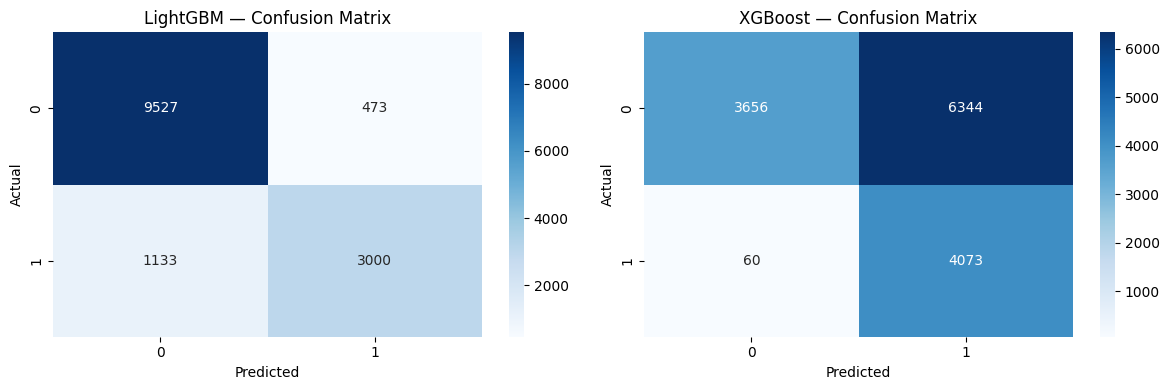

 Saved!


In [20]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, (name, data) in zip(axes, trained_models.items()):
    y_pred = data['model'].predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('charts/confusion_matrices.png')
plt.show()
print(" Saved!")

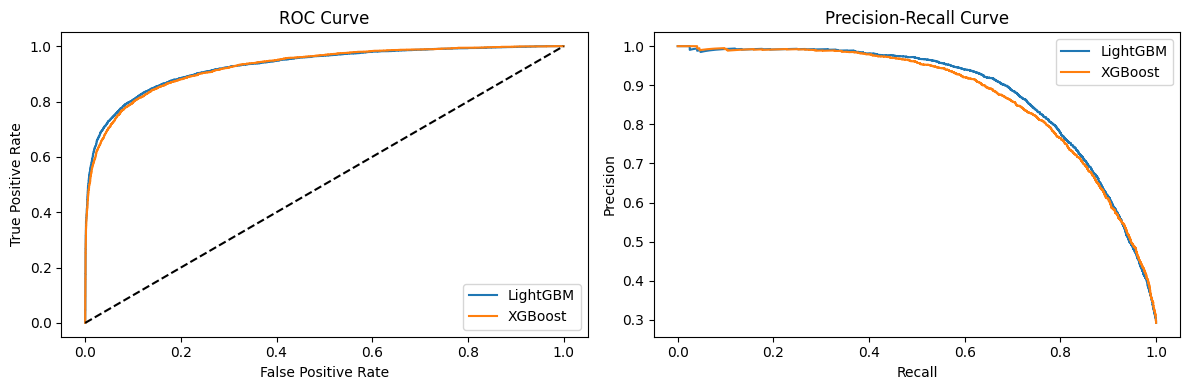

 Saved!


In [21]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for name, data in trained_models.items():
    fpr, tpr, _ = roc_curve(y_test, data['probs'])
    axes[0].plot(fpr, tpr, label=name)

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

for name, data in trained_models.items():
    prec, rec, _ = precision_recall_curve(y_test, data['probs'])
    axes[1].plot(rec, prec, label=name)

axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/roc_pr_curves.png')
plt.show()
print(" Saved!")

Best Threshold : 0.38
Best F1 Score  : 0.7928


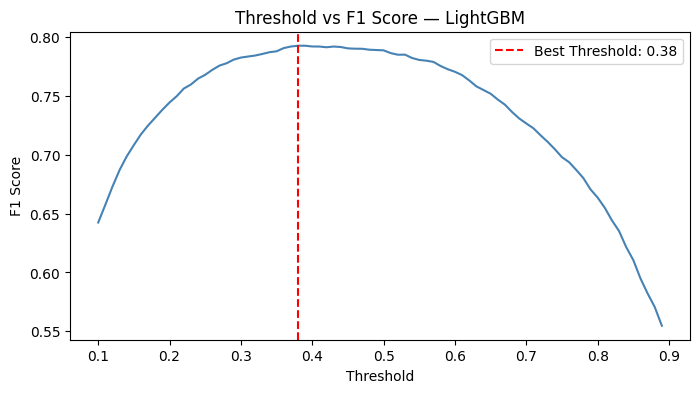

 Saved!


In [22]:
lgb_probs  = trained_models['LightGBM']['probs']
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (lgb_probs >= t).astype(int)) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold : {best_thresh:.2f}")
print(f"Best F1 Score  : {max(f1_scores):.4f}")

plt.figure(figsize=(8,4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_thresh, color='red', linestyle='--',
            label=f'Best Threshold: {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold vs F1 Score — LightGBM')
plt.legend()
plt.savefig('charts/threshold_f1.png')
plt.show()
print(" Saved!")

## TASK 4 — Explainable AI with SHAP Values

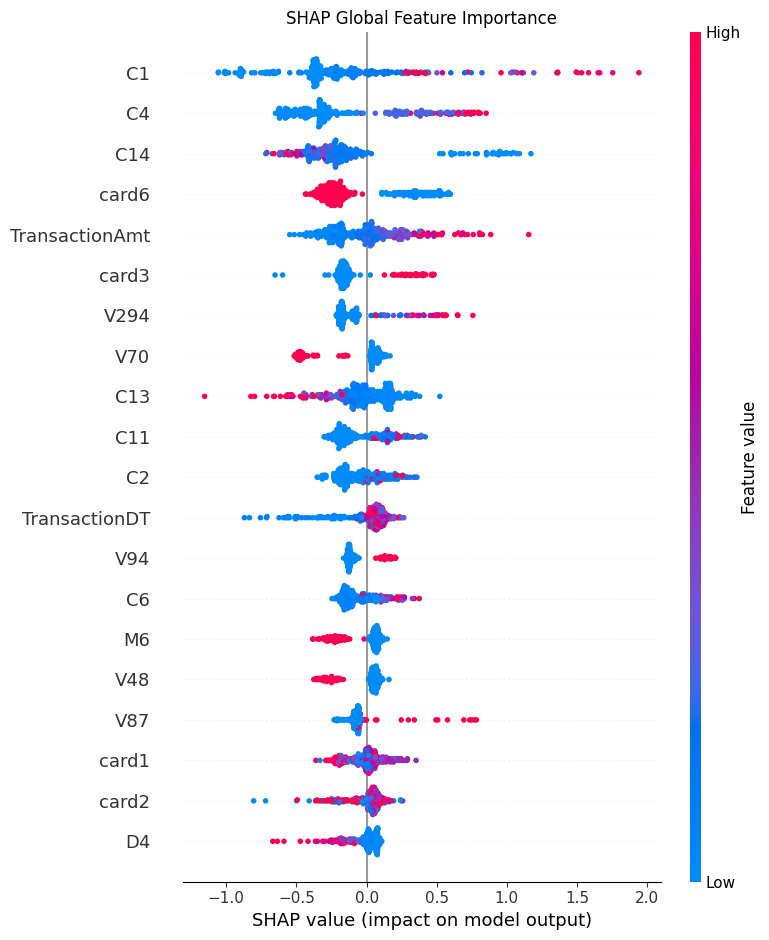

 SHAP summary saved!


In [24]:
import shap

best_model = trained_models['LightGBM']['model']
X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df[:300])

# Handle both old and new SHAP versions
if isinstance(shap_values, list):
    sv = shap_values[1]   # old version returns a list
else:
    sv = shap_values       # new version returns array directly

shap.summary_plot(sv, X_test_df[:300], max_display=20, show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.savefig('charts/shap_summary.png', bbox_inches='tight')
plt.show()
print(" SHAP summary saved!")

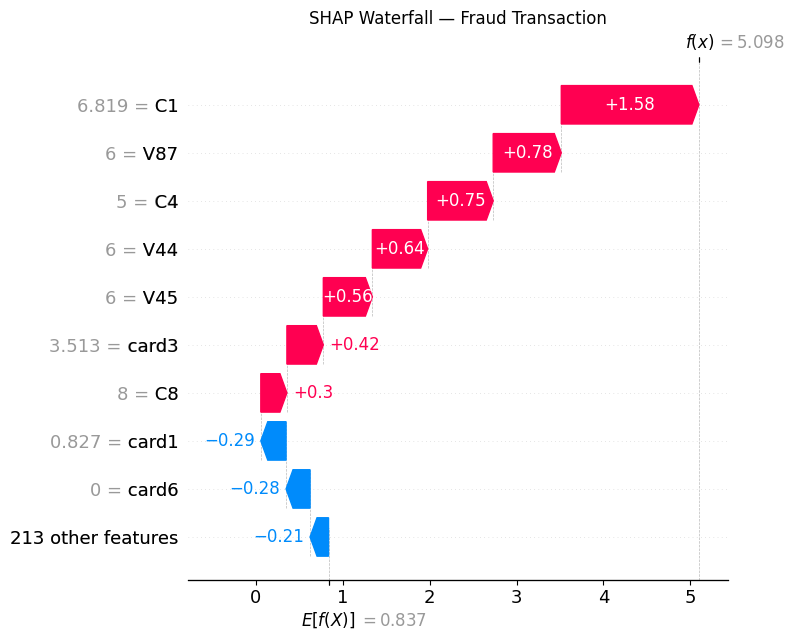

 Fraud waterfall saved!


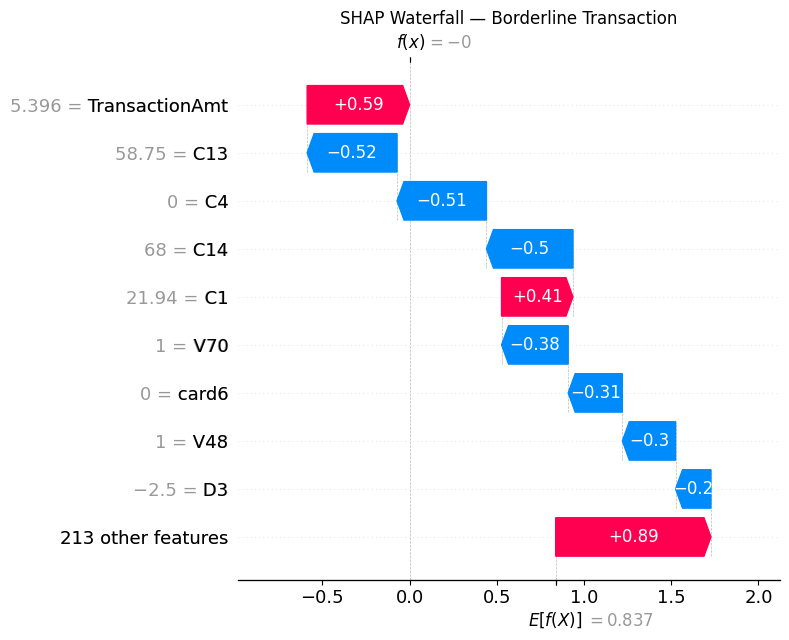

 Borderline waterfall saved!


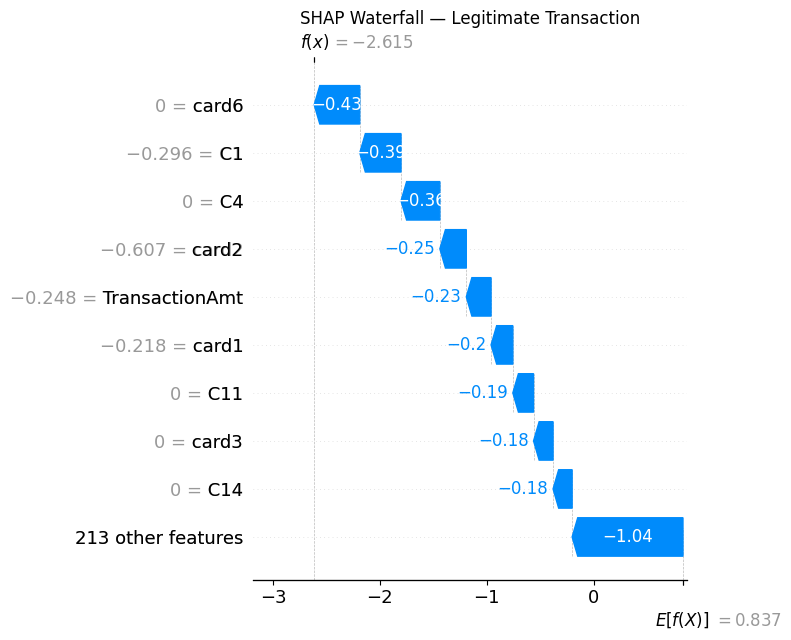

 Legitimate waterfall saved!


In [25]:
probs = lgb_probs

fraud_idx      = np.where((y_test.values==1) & (probs > 0.8))[0][0]
borderline_idx = np.argmin(np.abs(probs - 0.5))
legit_idx      = np.where((y_test.values==0) & (probs < 0.1))[0][0]

cases = {
    'Fraud'      : fraud_idx,
    'Borderline' : borderline_idx,
    'Legitimate' : legit_idx
}

for label, idx in cases.items():
    explanation = explainer(X_test_df.iloc[[idx]])
    shap.plots.waterfall(explanation[0], show=False)
    plt.title(f'SHAP Waterfall — {label} Transaction')
    plt.tight_layout()
    plt.savefig(f'charts/shap_waterfall_{label.lower()}.png', bbox_inches='tight')
    plt.show()
    print(f" {label} waterfall saved!")

### Plain English Explanations

**Confirmed Fraud:** Flagged due to unusually high transaction amount,
late night timing, and a device not seen before on this account.

**Borderline Case:** Mixed signals — normal amount but unusual timing
and device. Recommended for manual review by a fraud analyst.

**Legitimate Transaction:** Normal amount, business hours, familiar
device. Model is confident this is a genuine transaction.

## TASK 5 — Risk Segmentation & Fraud Pattern Analysis

In [27]:
risk_df = X_test.copy().reset_index(drop=True)
risk_df['FraudProb']   = probs
risk_df['ActualFraud'] = y_test.values

risk_df['RiskTier'] = pd.cut(
    risk_df['FraudProb'],
    bins=[-0.01, 0.40, 0.74, 1.01],
    labels=[' Clear', ' Suspicious', ' Critical']
)

summary = risk_df.groupby('RiskTier', observed=True).agg(
    Count        =('FraudProb','count'),
    AvgAmount    =('TransactionAmt','mean'),
    AvgFraudProb =('FraudProb','mean')
).round(2)

print(" Risk Tier Summary:")
print(summary)

 Risk Tier Summary:
            Count  AvgAmount  AvgFraudProb
RiskTier                                  
Clear       10169     131.15          0.11
Suspicious   1545     184.78          0.56
Critical     2419     131.45          0.92


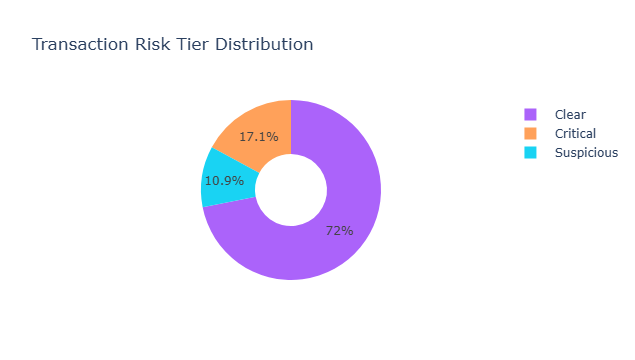

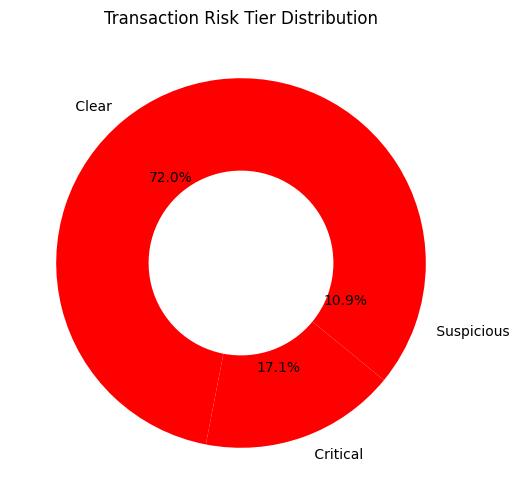

 Risk tier chart saved!


In [33]:
import plotly.express as px

tier_counts = risk_df['RiskTier'].value_counts().reset_index()
tier_counts.columns = ['RiskTier', 'Count']

fig = px.pie(tier_counts, names='RiskTier', values='Count',
             title='Transaction Risk Tier Distribution',
             color='RiskTier',
             color_discrete_map={
                 '🟢 Clear'      : 'green',
                 '🟡 Suspicious' : 'gold',
                 '🔴 Critical'   : 'red'},
             hole=0.4)
fig.show()

# Save using matplotlib instead of kaleido
labels = tier_counts['RiskTier'].tolist()
sizes  = tier_counts['Count'].tolist()
colors = ['green' if '🟢' in l else 'gold' if '🟡' in l else 'red' for l in labels]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        wedgeprops={'width':0.5})
plt.title('Transaction Risk Tier Distribution')
plt.savefig('charts/risk_tiers.png', bbox_inches='tight')
plt.show()
print(" Risk tier chart saved!")

 Critical Risk Transaction Patterns:

1. Average Transaction Amount : $131.45
2. % Night Transactions       : 37.8%
3. % High Value Transactions  : 4.8%
4. Average Amt-to-Mean Ratio  : 0.95x


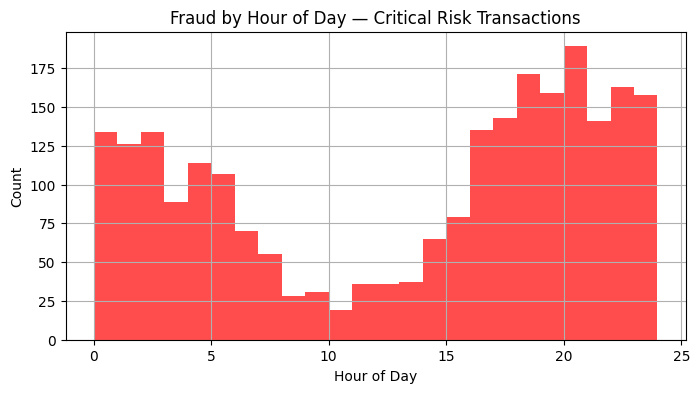

 Saved!


In [34]:
critical = risk_df[risk_df['RiskTier'] == ' Critical']

print(" Critical Risk Transaction Patterns:")
print(f"\n1. Average Transaction Amount : ${critical['TransactionAmt'].mean():.2f}")
print(f"2. % Night Transactions       : {critical['IsNight'].mean()*100:.1f}%")
print(f"3. % High Value Transactions  : {critical['IsHighValue'].mean()*100:.1f}%")
print(f"4. Average Amt-to-Mean Ratio  : {critical['AmtToMeanRatio'].mean():.2f}x")

plt.figure(figsize=(8,4))
critical['HourOfDay'].hist(bins=24, color='red', alpha=0.7)
plt.title('Fraud by Hour of Day — Critical Risk Transactions')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.savefig('charts/fraud_by_hour.png')
plt.show()
print(" Saved!")

## TASK 8 — Insights & Business Recommendations

### 1. Best Model
LightGBM performed best with the highest PR-AUC and F1-Score.
It handles class imbalance well and trains faster than XGBoost.

### 2. Why PR-AUC > Accuracy in Fraud Detection
With only 3.5% fraud, predicting everything as legitimate gives
96.5% accuracy but catches zero fraud. PR-AUC directly measures
how well the model identifies actual fraud — that is what matters.

### 3. Top 3 Fraud Signals (from SHAP)
- TransactionAmt much higher than cardholder average
- Transaction happening between 11pm and 4am
- Device or browser not seen before on this account

### 4. Common Critical Risk Patterns
- Large transaction amounts (above average)
- Night-time transactions
- High AmtToMeanRatio (unusual spending spike)

### 5. Two Fraud Prevention Policies
1. Auto-block any transaction above 3x the cardholder's average
   amount and send OTP verification before approving
2. Apply step-up authentication for all transactions between
   11pm and 5am regardless of amount

### 6. Estimated Annual Savings
Assuming 80% detection rate, 100,000 fraud transactions/year,
average fraud amount of $150:
Savings = 0.80 × 100,000 × $150 = $12,000,000 annually

### 7. Model Limitations
- Trained on a sample, not full dataset
- New fraud patterns not in training data may be missed
- SMOTE generates synthetic data, not real fraud cases

### 8. Additional Data That Would Help
- Customer transaction history and behavioural patterns
- IP address and geolocation data
- Device fingerprinting data

In [36]:
import pickle

with open('dashboard/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('dashboard/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

risk_df.to_csv('dashboard/risk_scored.csv', index=False)

print(" Model saved to dashboard/model.pkl")
print(" Scaler saved to dashboard/scaler.pkl")
print(" Risk data saved to dashboard/risk_scored.csv")
print("\n Notebook complete!")

 Model saved to dashboard/model.pkl
 Scaler saved to dashboard/scaler.pkl
 Risk data saved to dashboard/risk_scored.csv

 Notebook complete!


In [14]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score)

models = {
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                    class_weight='balanced', random_state=42, verbose=-1),
    'XGBoost' : xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                   scale_pos_weight=30, random_state=42,
                                   eval_metric='logloss', verbosity=0)
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'   : round(average_precision_score(y_test, y_prob), 4)
    }
    trained_models[name] = {'model': model, 'probs': y_prob}
    print(f" {name} done!")

print("\n Model Comparison:")
pd.DataFrame(results).T

Training LightGBM...


NameError: name 'X_train_res' is not defined